# Pattern Selection Framework

This notebook implements the three-phase Pattern Selection Framework to systematically evaluate, filter, and select trading patterns for the multi-pattern confluence system.

**Objective**: Identify patterns that provide unique, positive marginal contribution to the overall system.

## Three-Phase Approach
1. **Phase 1: Isolated Performance Baseline** - Solo backtests for all patterns with noise filtering
2. **Phase 2: Statistical Correlation Analysis** - Identify redundant patterns using equity curve correlation
3. **Phase 3: Ablation Testing** - Leave-one-out analysis to measure marginal contribution

---

## Quick Configuration Guide

Modify the `CONFIG` dictionary in Section 1 to customize:
- Data source and date range
- Backtest parameters (capital, commission, risk)
- Phase 1/2/3 thresholds for pattern filtering
- Output directory and visualization options

---

## 1. Configuration Section

**Modify parameters below to customize the pattern selection process.**

In [1]:
# ============================================================
# CONFIGURATION - Modify these parameters to customize analysis
# ============================================================

CONFIG = {
    # ----------------------------------------------------------
    # Data Configuration
    # ----------------------------------------------------------
    "data": {
        "file": "SPY_daily.csv",  # Data file name
        "directory": "data/raw",  # Data directory
        "start_date": None,  # Start date filter (None = all)
        "end_date": None,  # End date filter (None = all)
        "columns": ["Open", "High", "Low", "Close", "Volume"],
    },
    # ----------------------------------------------------------
    # Backtest Configuration
    # ----------------------------------------------------------
    "backtest": {
        "initial_equity": 100000.0,  # Starting capital
        "commission": 0.001,  # Commission rate (0.1%)
        "exclusive_orders": True,  # Close positions before opening new
        "min_confluence_count": 2,  # Minimum patterns for signal
    },
    # ----------------------------------------------------------
    # Pattern Selection Thresholds
    # ----------------------------------------------------------
    "selection": {
        # Phase 1: Noise Filtering Thresholds
        "min_trades": 30,  # Minimum trades for statistical significance
        "min_sharpe": 0.5,  # Minimum Sharpe ratio
        "min_profit_factor": 1.0,  # Minimum profit factor
        "min_win_rate": 0.40,  # Minimum win rate (40%)
        "max_drawdown": 0.30,  # Maximum drawdown (30%)
        # Phase 2: Correlation Analysis
        "correlation_threshold": 0.8,  # Patterns with correlation > 0.8 are redundant
        # Phase 3: Ablation Testing
        "positive_contribution_threshold": 0.0,  # Keep patterns with positive delta Sharpe
        "noise_threshold": -0.05,  # Patterns below this are noise generators
        "primary_signal_threshold": 0.1,  # Patterns above this are primary signals
    },
    # ----------------------------------------------------------
    # Quick Test Mode (for faster iteration)
    # ----------------------------------------------------------
    "quick_test": {
        "enabled": False,  # Set True to test with subset of patterns
        "num_patterns": 5,  # Number of patterns to test
        "relaxed_thresholds": {  # Relaxed thresholds for quick testing
            "min_trades": 5,
            "min_sharpe": 0.0,
            "min_profit_factor": 0.0,
            "min_win_rate": 0.0,
            "max_drawdown": 1.0,
        },
    },
    # ----------------------------------------------------------
    # Output Configuration
    # ----------------------------------------------------------
    "output": {
        "directory": "reports/pattern_selection",
        "save_results": True,  # Save CSV/JSON results
        "save_plots": True,  # Save visualization plots
        "show_plots": True,  # Display plots in notebook
        "dpi": 150,  # Plot resolution
    },
}

---

## 2. Setup and Imports

In [2]:
# ============================================================
# Setup and Imports
# ============================================================
import warnings
import sys
from pathlib import Path

warnings.filterwarnings("ignore")

# Add project root to sys.path so 'src' imports work
# Try multiple candidates to find the correct project root
candidates = [
    Path(".").resolve().parent.parent,
    Path(".").resolve(),
    Path(".").resolve().parent,
]
project_root = None
for candidate in candidates:
    if candidate and (candidate / "src").exists():
        project_root = candidate
        break
if project_root is None:
    project_root = Path(".").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import notebook helpers
from src.utils.notebook_helpers import (
    setup_project_root,
    load_price_data,
    print_data_summary,
    get_output_path,
)

# Import pattern selection framework
from src.analysis.pattern_selector import PatternSelector
from src.utils.notebook_helpers import PatternSelectionConfig
from src.analysis.pattern_selector_viz import (
    generate_all_visualizations,
)

# Re-confirm project root (in case notebook is in a subdirectory)
project_root = setup_project_root()

# Standard imports
import pandas as pd
import matplotlib.pyplot as plt
import os

# Configure display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("✅ Imports successful!")
print(f"Project root: {project_root}")

Loading BokehJS ...

✅ Imports successful!
Project root: C:\Dev\projects\investment_trying


---

## 3. Load and Prepare Data

In [3]:
# Load data using helper function
df = load_price_data(CONFIG, project_root)

# Display data summary
print_data_summary(df, title="SPY Daily Data Summary")

📊 SPY Daily Data Summary
Date Range: 2015-01-02 to 2024-12-30
Total Trading Days: 2,515
Years of Data: 10.0

Columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Data shape: (2515, 5)

First 5 rows:
                  Open        High         Low       Close     Volume
Date                                                                 
2015-01-02  170.911759  171.325830  169.089839  170.125015  121465900
2015-01-05  169.081555  169.247181  166.746204  167.052612  169632600
2015-01-06  167.359012  167.880745  164.684120  165.479141  209151400
2015-01-07  166.804154  167.880740  166.356963  167.541199  125346700
2015-01-08  168.949050  170.729561  168.932497  170.514236  147217800

📈 Price Statistics:
          Open     High      Low    Close
count  2515.00  2515.00  2515.00  2515.00
mean    309.32   310.99   307.49   309.36
std     114.06   114.62   113.43   114.07
min     154.12   155.61   152.47   154.56
25%     211.66   212.23   210.84   211.59
50%     272.46   273.05   271.45   272

---

## 4. Configure Pattern Selection

Create the `PatternSelectionConfig` from the CONFIG dictionary.

In [4]:
# Build data path
data_path = project_root / CONFIG["data"]["directory"] / CONFIG["data"]["file"]

# Get selection config values
sel_config = CONFIG["selection"]
quick_test = CONFIG["quick_test"]

# Apply quick test relaxed thresholds if enabled
if quick_test["enabled"]:
    relaxed = quick_test["relaxed_thresholds"]
    min_trades = relaxed["min_trades"]
    min_sharpe = relaxed["min_sharpe"]
    min_profit_factor = relaxed["min_profit_factor"]
    min_win_rate = relaxed["min_win_rate"]
    max_drawdown = relaxed["max_drawdown"]
    print("⚡ Quick Test Mode ENABLED - Using relaxed thresholds")
else:
    min_trades = sel_config["min_trades"]
    min_sharpe = sel_config["min_sharpe"]
    min_profit_factor = sel_config["min_profit_factor"]
    min_win_rate = sel_config["min_win_rate"]
    max_drawdown = sel_config["max_drawdown"]

# Create PatternSelectionConfig
config = PatternSelectionConfig(
    data_path=str(data_path),
    output_dir=CONFIG["output"]["directory"],
    # Backtest configuration
    initial_equity=CONFIG["backtest"]["initial_equity"],
    commission=CONFIG["backtest"]["commission"],
    min_confluence_count=CONFIG["backtest"]["min_confluence_count"],
    # Phase 1 thresholds (Noise Filtering)
    min_trades=min_trades,
    min_sharpe=min_sharpe,
    min_profit_factor=min_profit_factor,
    min_win_rate=min_win_rate,
    max_drawdown=max_drawdown,
    # Phase 2 thresholds (Correlation Analysis)
    correlation_threshold=sel_config["correlation_threshold"],
    # Phase 3 thresholds (Ablation Testing)
    positive_contribution_threshold=sel_config["positive_contribution_threshold"],
    noise_threshold=sel_config["noise_threshold"],
    primary_signal_threshold=sel_config["primary_signal_threshold"],
    # Output configuration
    cache_results=CONFIG["output"]["save_results"],
)

# Validate configuration
errors = config.validate()
if errors:
    print("❌ Configuration errors:")
    for error in errors:
        print(f"  - {error}")
else:
    print("✅ Configuration validated successfully")

# Print configuration summary
print("\n📋 Pattern Selection Configuration:")
print("=" * 60)
print(f"Data path: {config.data_path}")
print(f"Output directory: {config.output_dir}")
print("\nPhase 1 Thresholds (Noise Filtering):")
print(f"  Minimum trades: {config.min_trades}")
print(f"  Minimum Sharpe ratio: {config.min_sharpe}")
print(f"  Minimum profit factor: {config.min_profit_factor}")
print(f"  Minimum win rate: {config.min_win_rate:.0%}")
print(f"  Maximum drawdown: {config.max_drawdown:.0%}")
print("\nPhase 2 Thresholds (Correlation Analysis):")
print(f"  Correlation threshold: {config.correlation_threshold}")
print("\nPhase 3 Thresholds (Ablation Testing):")
print(f"  Positive contribution threshold: {config.positive_contribution_threshold}")
print(f"  Noise threshold: {config.noise_threshold}")
print(f"  Primary signal threshold: {config.primary_signal_threshold}")

✅ Configuration validated successfully

📋 Pattern Selection Configuration:
Data path: C:\Dev\projects\investment_trying\data\raw\SPY_daily.csv
Output directory: reports/pattern_selection

Phase 1 Thresholds (Noise Filtering):
  Minimum trades: 30
  Minimum Sharpe ratio: 0.5
  Minimum profit factor: 1.0
  Minimum win rate: 40%
  Maximum drawdown: 30%

Phase 2 Thresholds (Correlation Analysis):
  Correlation threshold: 0.8

Phase 3 Thresholds (Ablation Testing):
  Positive contribution threshold: 0.0
  Noise threshold: -0.05
  Primary signal threshold: 0.1


---

## 5. Initialize Pattern Selector

In [5]:
# Initialize pattern selector
print("🔧 Initializing Pattern Selector...")
selector = PatternSelector(config)

# Display all patterns to be tested
print(f"\n📋 Found {len(selector.all_patterns)} patterns to test:")
for i, pattern in enumerate(selector.all_patterns, 1):
    print(f"  {i:2d}. {pattern}")

# Apply quick test mode if enabled
if CONFIG["quick_test"]["enabled"]:
    num_patterns = CONFIG["quick_test"]["num_patterns"]
    selector.all_patterns = selector.all_patterns[:num_patterns]
    print(f"\n⚡ Quick test mode: Testing with {len(selector.all_patterns)} patterns")

🔧 Initializing Pattern Selector...

📋 Found 35 patterns to test:
   1. Market Structure Low
   2. Matching Lows
   3. NR7ID
   4. n-Bar Decline
   5. Floor Pivot Breakout
   6. Two-Bar Reversal
   7. Gartley Pattern
   8. ABC Pattern
   9. Symmetric Triangle
  10. Bollinger Bands
  11. Donchian Channel Breakout
  12. Cup and Handle
  13. Head and Shoulders
  14. Spike and Ledge
  15. Three Hills and Mountain
  16. Parabolic Arc
  17. Double Top
  18. Double Bottom
  19. Trader Vic's 2B
  20. Triple Top
  21. Triple Bottom
  22. Ascending Triangle
  23. Descending Triangle
  24. Rectangle
  25. Wedge
  26. Dead Cat Bounce
  27. Flag
  28. Pennant
  29. Gap Pattern
  30. Doji
  31. Harami
  32. Hammer
  33. Engulfing
  34. Dark Cloud Cover
  35. Piercing Line


---

## 6. Run Full Pattern Selection Process

**Estimated Time**: ~20-30 minutes for all 35 patterns (or ~2-3 minutes in quick test mode)

In [6]:
# Run the complete selection process
print("\n" + "=" * 60)
print("🚀 Starting Pattern Selection Process")
print("=" * 60)
print("\nThis will run three phases:")
print("  Phase 1: Solo backtests for all patterns")
print("  Phase 2: Correlation analysis of equity curves")
print("  Phase 3: Leave-one-out ablation testing")

if CONFIG["quick_test"]["enabled"]:
    print("\n⚡ Quick test mode - estimated time: ~2-3 minutes")
else:
    print("\nEstimated total time: ~20-30 minutes for all patterns")
print("=" * 60)

# Run full selection
result = selector.run_full_pipeline(selector.all_patterns, df)

print("\n" + "=" * 60)
print("✅ Pattern Selection Complete!")
print("=" * 60)

INFO:src.analysis.pattern_selector:Starting pattern selection pipeline with 35 candidates



🚀 Starting Pattern Selection Process

This will run three phases:
  Phase 1: Solo backtests for all patterns
  Phase 2: Correlation analysis of equity curves
  Phase 3: Leave-one-out ablation testing

Estimated total time: ~20-30 minutes for all patterns


INFO:src.analysis.pattern_selector:Stage 1 (Stat+Perf) passed: 0/35



✅ Pattern Selection Complete!


---

## 7. Generate Visualizations and Reports

In [7]:
# Generate all visualizations
print("\n" + "=" * 60)
print("📊 Generating Visualizations and Reports")
print("=" * 60)

viz_outputs = generate_all_visualizations(result, config.output_dir)

print("\n📁 Generated outputs:")
for name, path in viz_outputs.items():
    if path:
        print(f"  ✅ {name}: {path}")
    else:
        print(f"  ⚠️ {name}: Not generated")


📊 Generating Visualizations and Reports

Generating Visualizations and Reports


INFO:src.analysis.pattern_selector_viz:  Funnel chart saved to: reports/pattern_selection\selection_funnel.png


INFO:src.analysis.pattern_selector_viz:  Report saved to: reports/pattern_selection\selection_report.md



📁 Generated outputs:
  ✅ selection_funnel: reports/pattern_selection\selection_funnel.png
  ⚠️ role_distribution: Not generated
  ✅ report: reports/pattern_selection\selection_report.md


---

## 8. Visualize Results Inline


📊 1. Selection Funnel:


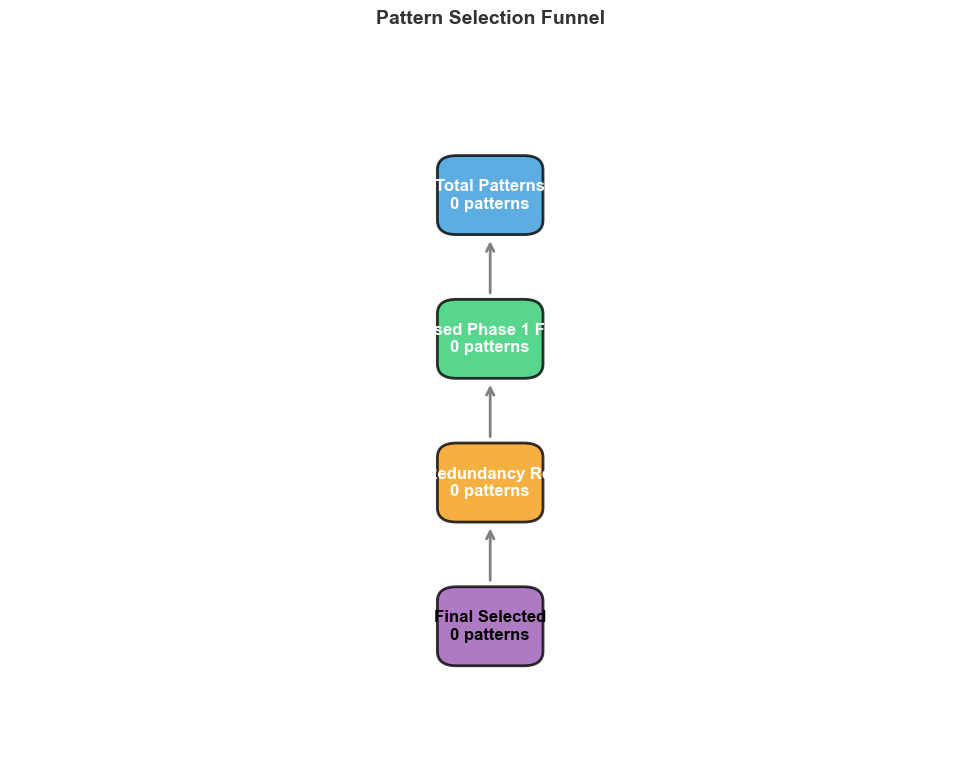

In [8]:
# Import visualization functions
from src.analysis.pattern_selector_viz import (
    plot_selection_funnel,
    plot_solo_performance,
    plot_role_distribution,
    plot_equity_curves_comparison,
)

# 1. Selection Funnel
print("\n📊 1. Selection Funnel:")
fig1 = plot_selection_funnel(result)
if CONFIG["output"]["show_plots"]:
    plt.show()
else:
    plt.close()

In [9]:
# 2. Solo Performance
print("\n📊 2. Solo Performance:")
fig2 = plot_solo_performance(result)
if CONFIG["output"]["show_plots"]:
    plt.show()
else:
    plt.close()


📊 2. Solo Performance:


In [10]:
# 3. Role Distribution (if patterns selected)
print("\n📊 3. Role Distribution:")
fig3 = plot_role_distribution(result)
if fig3:
    if CONFIG["output"]["show_plots"]:
        plt.show()
    else:
        plt.close()
else:
    print("  No patterns selected - role distribution not available")


📊 3. Role Distribution:
  No patterns selected - role distribution not available


In [11]:
# 4. Equity Curves Comparison (if patterns selected)
print("\n📊 4. Equity Curves Comparison:")
fig4 = plot_equity_curves_comparison(result)
if fig4:
    if CONFIG["output"]["show_plots"]:
        plt.show()
    else:
        plt.close()
else:
    print("  No equity curves available for comparison")


📊 4. Equity Curves Comparison:
  No equity curves available for comparison


---

## 9. Solo Performance Summary

In [12]:
# Create solo performance summary
if result.solo_results:
    print("\n📊 Solo Performance Summary:")

    # Create DataFrame
    solo_df = pd.DataFrame(
        [
            {
                "pattern": r.pattern_name,
                "sharpe": r.sharpe_ratio,
                "win_rate": r.win_rate,
                "profit_factor": r.profit_factor,
                "total_return": r.total_return_pct,
                "max_dd": r.max_drawdown_pct,
                "trades": r.total_trades,
                "passed": r.passed_filter,
            }
            for r in result.solo_results
        ]
    )

    # Sort by Sharpe ratio
    solo_df = solo_df.sort_values("sharpe", ascending=True)

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Color scheme
    colors = ["#2ecc71" if p else "#e74c3c" for p in solo_df["passed"]]

    # Plot 1: Sharpe Ratio
    ax1 = axes[0, 0]
    ax1.barh(solo_df["pattern"], solo_df["sharpe"], color=colors, edgecolor="black", linewidth=0.5)
    ax1.axvline(
        x=config.min_sharpe,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Threshold ({config.min_sharpe})",
    )
    ax1.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    ax1.set_xlabel("Sharpe Ratio", fontsize=11)
    ax1.set_title("Sharpe Ratio by Pattern", fontsize=12, fontweight="bold")
    ax1.legend(loc="lower right", fontsize=9)
    ax1.grid(axis="x", alpha=0.3, linestyle="--")

    # Plot 2: Win Rate
    ax2 = axes[0, 1]
    ax2.barh(
        solo_df["pattern"],
        solo_df["win_rate"] * 100,
        color=colors,
        edgecolor="black",
        linewidth=0.5,
    )
    ax2.axvline(
        x=config.min_win_rate * 100,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Threshold ({config.min_win_rate * 100:.0f}%)",
    )
    ax2.set_xlabel("Win Rate (%)", fontsize=11)
    ax2.set_title("Win Rate by Pattern", fontsize=12, fontweight="bold")
    ax2.legend(loc="lower right", fontsize=9)
    ax2.grid(axis="x", alpha=0.3, linestyle="--")

    # Plot 3: Profit Factor
    ax3 = axes[1, 0]
    ax3.barh(
        solo_df["pattern"], solo_df["profit_factor"], color=colors, edgecolor="black", linewidth=0.5
    )
    ax3.axvline(
        x=config.min_profit_factor,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Threshold ({config.min_profit_factor})",
    )
    ax3.set_xlabel("Profit Factor", fontsize=11)
    ax3.set_title("Profit Factor by Pattern", fontsize=12, fontweight="bold")
    ax3.legend(loc="lower right", fontsize=9)
    ax3.grid(axis="x", alpha=0.3, linestyle="--")

    # Plot 4: Total Return
    ax4 = axes[1, 1]
    ax4.barh(
        solo_df["pattern"], solo_df["total_return"], color=colors, edgecolor="black", linewidth=0.5
    )
    ax4.axvline(x=0, color="black", linestyle="-", linewidth=1)
    ax4.set_xlabel("Total Return (%)", fontsize=11)
    ax4.set_title("Total Return by Pattern", fontsize=12, fontweight="bold")
    ax4.grid(axis="x", alpha=0.3, linestyle="--")

    fig.suptitle("Pattern Solo Performance Metrics", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()

    if CONFIG["output"]["save_plots"]:
        save_path = get_output_path(CONFIG, project_root, "solo_performance_detailed.png")  # type: ignore[arg-type]
        fig.savefig(save_path, dpi=CONFIG["output"]["dpi"], bbox_inches="tight")

    if CONFIG["output"]["show_plots"]:
        plt.show()
    else:
        plt.close()

    # Display performance table
    print("\n📋 Top 10 Patterns by Sharpe Ratio:")
    top_sharpe = solo_df.sort_values("sharpe", ascending=False).head(10)
    display(
        top_sharpe[
            [
                "pattern",
                "sharpe",
                "win_rate",
                "profit_factor",
                "total_return",
                "max_dd",
                "trades",
                "passed",
            ]
        ]
    )
else:
    print("No solo results available.")

No solo results available.


---

## 10. Summary and Analysis

In [13]:
# Display comprehensive summary
summary = result.get_summary()

print("=" * 60)
print("📊 PATTERN SELECTION SUMMARY")
print("=" * 60)

print("\n📈 Selection Process Results:")
print(f"  • Total patterns evaluated: {summary['total_patterns_tested']}")
print(f"  • Patterns passing solo filter: {summary['passed_phase1_filter']}")
print(f"  • Patterns excluded (Phase 1): {summary['excluded_phase1']}")
print(f"  • Redundant pairs identified: {summary['redundant_pairs_found']}")
print(f"  • Final selected patterns: {summary['final_selected_patterns']}")

print(f"\n⏱️ Execution Time: {summary['execution_time_seconds']:.1f}s")
if result.phase_timings:
    print("\nPhase Timings:")
    for phase, timing in result.phase_timings.items():
        print(f"  • {phase.upper()}: {timing:.1f}s")

# Role classification
role_dist = result.get_role_distribution()
if role_dist:
    print("\n🎯 Pattern Role Classification:")
    for role, count in role_dist.items():
        print(f"  • {role}: {count} patterns")

# Display final selected patterns
if result.final_patterns:
    print(f"\n✅ Final Selected Patterns ({len(result.final_patterns)}):")
    for i, pattern in enumerate(result.final_patterns, 1):
        c = next(
            (
                c
                for c in result.ablation_contributions
                if (c.pattern_name if hasattr(c, "pattern_name") else c.get("pattern_name", ""))
                == pattern
            ),
            None,
        )
        if c:
            role_name = (
                c.role.value
                if hasattr(c.role, "value")
                else (c.role if hasattr(c, "role") else c.get("role", "Unknown"))
            )
            print(f"  {i:2d}. {pattern} ({role_name}, δ Sharpe: {c.delta_sharpe:.4f})")
        else:
            print(f"  {i:2d}. {pattern}")
else:
    print("\n⚠️ No patterns passed selection criteria.")
    print("   Consider adjusting thresholds in the CONFIG section.")

📊 PATTERN SELECTION SUMMARY

📈 Selection Process Results:
  • Total patterns evaluated: 34
  • Patterns passing solo filter: 0
  • Patterns excluded (Phase 1): 34
  • Redundant pairs identified: 0
  • Final selected patterns: 0

⏱️ Execution Time: 0.0s

⚠️ No patterns passed selection criteria.
   Consider adjusting thresholds in the CONFIG section.


---

## 11. Export Results

In [14]:
# Results are already saved by the framework
# Display what was saved

output_dir = CONFIG["output"]["directory"]
print(f"📁 Files Generated in '{output_dir}':")
print("  • solo_results.csv - Solo performance metrics for all patterns")
print("  • correlation_matrix.csv - Correlation matrix of equity curves")
print("  • ablation_results.csv - Leave-one-out contribution analysis")
print("  • final_selection.json - Final selected patterns with criteria")
print("  • config.json - Configuration used for selection")
print("  • correlation_heatmap.png - Correlation visualization")
print("  • contribution_ranking.png - Marginal contribution chart")
print("  • solo_performance.png - Solo metrics dashboard")
print("  • selection_funnel.png - Pattern filtering funnel")
print("  • role_distribution.png - Pattern role pie chart")
print("  • selection_report.md - Detailed markdown report")

# Display the markdown report
report_path = os.path.join(output_dir, "selection_report.md")
if os.path.exists(report_path):
    print("\n📄 Selection Report Preview:")
    print("=" * 60)
    with open(report_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
        # Show first 50 lines
        for line in lines[:50]:
            print(line.rstrip())
    if len(lines) > 50:
        print(f"\n... ({len(lines) - 50} more lines)")

📁 Files Generated in 'reports/pattern_selection':
  • solo_results.csv - Solo performance metrics for all patterns
  • correlation_matrix.csv - Correlation matrix of equity curves
  • ablation_results.csv - Leave-one-out contribution analysis
  • final_selection.json - Final selected patterns with criteria
  • config.json - Configuration used for selection
  • correlation_heatmap.png - Correlation visualization
  • contribution_ranking.png - Marginal contribution chart
  • solo_performance.png - Solo metrics dashboard
  • selection_funnel.png - Pattern filtering funnel
  • role_distribution.png - Pattern role pie chart
  • selection_report.md - Detailed markdown report

📄 Selection Report Preview:
# Pattern Selection Report

*Generated by Pattern Selection Framework*

## Executive Summary

| Metric | Value |
|--------|-------|
| Total Patterns Tested | 34 |
| Passed Phase 1 Filter | 0 |
| Excluded (Phase 1) | 34 |
| Redundant Pairs Found | 0 |
| After Redundancy Removal | 0 |
| **Final

---

## 12. Quick Test Mode Instructions

For faster iteration during development, enable quick test mode in the CONFIG section.

In [15]:
print("=" * 60)
print("⚡ QUICK TEST MODE (Optional)")
print("=" * 60)
print("""
To run a quick test with only 5 patterns for faster verification:

1. In Section 1 (CONFIG), set:
   'quick_test': {
       'enabled': True,
       'num_patterns': 5,
       ...
   }

2. Re-run all cells from the beginning

Quick test uses relaxed thresholds by default:
  - Min trades: 5 (vs 30)
  - Min Sharpe: 0.0 (vs 0.5)
  - Min profit factor: 0.0 (vs 1.0)
  - Min win rate: 0% (vs 40%)
  - Max drawdown: 100% (vs 30%)

This allows you to see results quickly and verify the pipeline works.
Once satisfied, disable quick test mode and run with full thresholds.
""")

⚡ QUICK TEST MODE (Optional)

To run a quick test with only 5 patterns for faster verification:

1. In Section 1 (CONFIG), set:
   'quick_test': {
       'enabled': True,
       'num_patterns': 5,
       ...
   }

2. Re-run all cells from the beginning

Quick test uses relaxed thresholds by default:
  - Min trades: 5 (vs 30)
  - Min Sharpe: 0.0 (vs 0.5)
  - Min profit factor: 0.0 (vs 1.0)
  - Min win rate: 0% (vs 40%)
  - Max drawdown: 100% (vs 30%)

This allows you to see results quickly and verify the pipeline works.
Once satisfied, disable quick test mode and run with full thresholds.

